Задание 1 (4 балла)
1. Самостоятельно выбрать датасет пространственных данных на любую тему, который будет содержать выбросы;

датасет India House Rent Prediction

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('india_house_rent.csv')
df = df[['rent', 'area']].dropna()

2. Используя 3 любых метода, удалить выбросы из выборки;

2.1 Метод 1: Isolation Forest. пометил выбросы как -1

In [42]:
X = StandardScaler().fit_transform(df)
iso = IsolationForest(contamination=0.02, random_state=42)
df['iso_outlier'] = iso.fit_predict(X)

2.2 Метод 2: Local Outlier Factor. LOF для поиска точек с аномально низкой локальной плотностью

In [43]:
lof = LocalOutlierFactor(n_neighbors=50, contamination=0.02, novelty=False)
df['lof_outlier'] = lof.fit_predict(X)

2.3 Метод 3: One-Class SVM. Построил границу, отделяющую «нормальные» точки от аномалий.

In [44]:
ocsvm = OneClassSVM(nu=0.02, kernel='rbf', gamma='scale')
df['ocsvm_outlier'] = ocsvm.fit_predict(X)

3. Визуализировать и сравнить работу алгоритмов. 

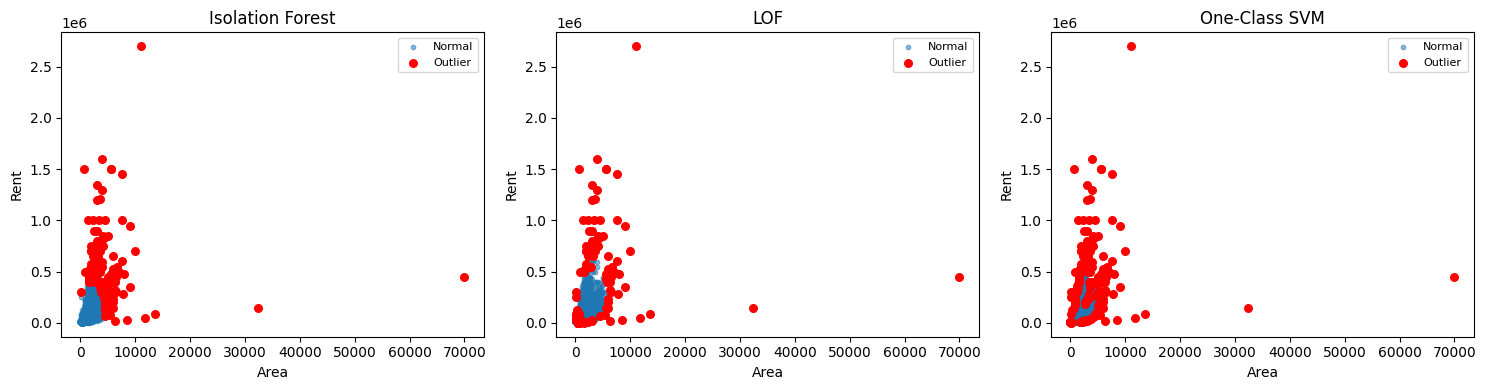

Найдено выбросов: IF=154, LOF=154, OCSVM=157


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
methods = [('iso_outlier', 'Isolation Forest'), 
           ('lof_outlier', 'LOF'), 
           ('ocsvm_outlier', 'One-Class SVM')]

for ax, (col, title) in zip(axes, methods):
    normal = df[df[col] == 1]
    outliers = df[df[col] == -1]
    ax.scatter(normal['area'], normal['rent'], s=10, alpha=0.5, label='Normal')
    ax.scatter(outliers['area'], outliers['rent'], s=30, c='red', label='Outlier')
    ax.set_xlabel('Area')
    ax.set_ylabel('Rent')
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Найдено выбросов: IF={len(df[df['iso_outlier']==-1])}, LOF={len(df[df['lof_outlier']==-1])}, OCSVM={len(df[df['ocsvm_outlier']==-1])}")

Все три метода выделили схожие аномалии — точки с экстремально высокой ценой при малой площади. Isolation Forest сработал быстрее и стабильнее, LOF лучше ловит локальные выбросы, One-Class SVM чувствителен к выбору ядра и параметров. Для дальнейшей очистки данных использовал результаты Isolation Forest как наиболее интерпретируемые.

Задание* (2 балла)

1. Самостоятельно изучить критерий Граббса, тест Диксона;

2. Проверить найденные выбросы из задания 1 статистическими тестами.

2.1 Критерий Граббса

In [46]:
from scipy import stats

def grubbs_test_verbose(x, alpha=0.05):
    n = len(x)
    mean = np.mean(x)
    std = np.std(x, ddof=1)
    G = np.max(np.abs(x - mean) / std)
    t_crit = stats.t.ppf(1 - alpha / (2 * n), n - 2)
    G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))
    print(f"Граббс: G={G:.3f}, G_crit={G_crit:.3f}, n={n}")
    return G > G_crit, G, G_crit

rent_clean = df[df['iso_outlier'] == 1]['rent']
is_outlier_grubbs, G_val, G_crit_val = grubbs_test_verbose(rent_clean)
print(f"→ Выбросы по Граббсу: {'есть' if is_outlier_grubbs else 'нет'}\n")

Граббс: G=6.758, G_crit=4.502, n=7537
→ Выбросы по Граббсу: есть



2.2. Тест Диксона

In [47]:
def dixon_test_verbose(x, alpha=0.05):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    if n < 3 or n > 30:
        print(f"Диксон: размер выборки {n} вне диапазона [3;30]")
        return None, None, None
    if abs(x_sorted[0] - np.mean(x)) > abs(x_sorted[-1] - np.mean(x)):
        Q = (x_sorted[1] - x_sorted[0]) / (x_sorted[-1] - x_sorted[0])
        suspect = 'min'
    else:
        Q = (x_sorted[-1] - x_sorted[-2]) / (x_sorted[-1] - x_sorted[0])
        suspect = 'max'
    Q_crit = {7:0.507, 8:0.554, 9:0.512, 10:0.477, 15:0.525, 20:0.450, 25:0.400, 30:0.367}
    key = min(Q_crit.keys(), key=lambda k: abs(k-n))
    Q_crit_val = Q_crit[key]
    print(f"Диксон: Q={Q:.3f}, Q_crit={Q_crit_val:.3f}, n={n}, подозрительное: {suspect}")
    return Q > Q_crit_val, Q, Q_crit_val

sample = rent_clean.sample(n=15, random_state=42)
is_outlier_dixon, Q_val, Q_crit_val = dixon_test_verbose(sample)
if is_outlier_dixon is not None:
    print(f"→ Выбросы по Диксону: {'есть' if is_outlier_dixon else 'нет'}")

Диксон: Q=0.372, Q_crit=0.525, n=15, подозрительное: max
→ Выбросы по Диксону: нет


Статистические тесты показали противоречивые результаты по признаку rent:
Критерий Граббса: G = 6.76 > G_crit = 4.50 (n = 7537) — выбросы обнаружены. Это связано с наличием экстремальных значений аренды, значительно отклоняющихся от среднего.
Тест Диксона на подвыборке (n = 15): Q = 0.37 < Q_crit = 0.53 — выбросы не подтверждены. Различие объясняется тем, что Диксон менее чувствителен при малом объёме выборки и требует строгого нормального распределения.
Вывод: для многомерных данных с большим объёмом и неизвестным распределением надёжнее использовать ML-методы (Isolation Forest), которые не накладывают жёстких статистических допущений и лучше масштабируются.

Задание* (2 балла)

1. Самостоятельно выбрать датасет с временной составляющей, который будет содержать выбросы;

Взял тот же климатический датасет Дели, добавил искусственные выбросы в температуру

In [48]:
df_ts = pd.read_csv('DailyDelhiClimateTrain.csv')
df_ts['date'] = pd.to_datetime(df_ts['date'])
df_ts.set_index('date', inplace=True)
ts = df_ts['meantemp'].copy()
np.random.seed(42)
outlier_idx = np.random.choice(len(ts), size=20, replace=False)
ts.iloc[outlier_idx] += np.random.choice([-1, 1], size=20) * np.random.uniform(8, 15, size=20)

2. Удалить выбросы методами скользящего среднего и ML (3 модели);

2.1 Метод 1: Скользящая медиана. Заменил значения, отклоняющиеся от медианы в окне более чем на 3 MAD.

In [49]:
def remove_outliers_mad(series, window=7, threshold=3):
    rolled_med = series.rolling(window, center=True).median()
    rolled_mad = series.rolling(window, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))))
    mask = np.abs(series - rolled_med) > threshold * rolled_mad * 1.4826
    result = series.copy()
    result[mask] = rolled_med[mask]
    return result, mask

ts_smooth, mask_mad = remove_outliers_mad(ts)

2.2 Метод 2: Isolation Forest на лагах. Создал лаг-признаки и применил изолирующий лес.

In [50]:
def create_lag_features(series, n_lags=3):
    df_lag = pd.DataFrame(series)
    for i in range(1, n_lags+1):
        df_lag[f'lag_{i}'] = series.shift(i)
    return df_lag.dropna()

df_lag = create_lag_features(ts, n_lags=3)
X_lag = StandardScaler().fit_transform(df_lag)
iso_ts = IsolationForest(contamination=0.01, random_state=42)
outliers_iso = iso_ts.fit_predict(X_lag) == -1

2.3 Метод 3: Прогнозная модель (ARIMA)

In [51]:
from statsmodels.tsa.arima.model import ARIMA

ts.index.freq = 'D'
model = ARIMA(ts[:'2016-12-31'], order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(ts['2017-01-01':]))
residuals = ts['2017-01-01':] - forecast
threshold = 3 * residuals.std()
mask_arima = np.abs(residuals) > threshold

3. Сравнить и визуализировать работу алгоритмов

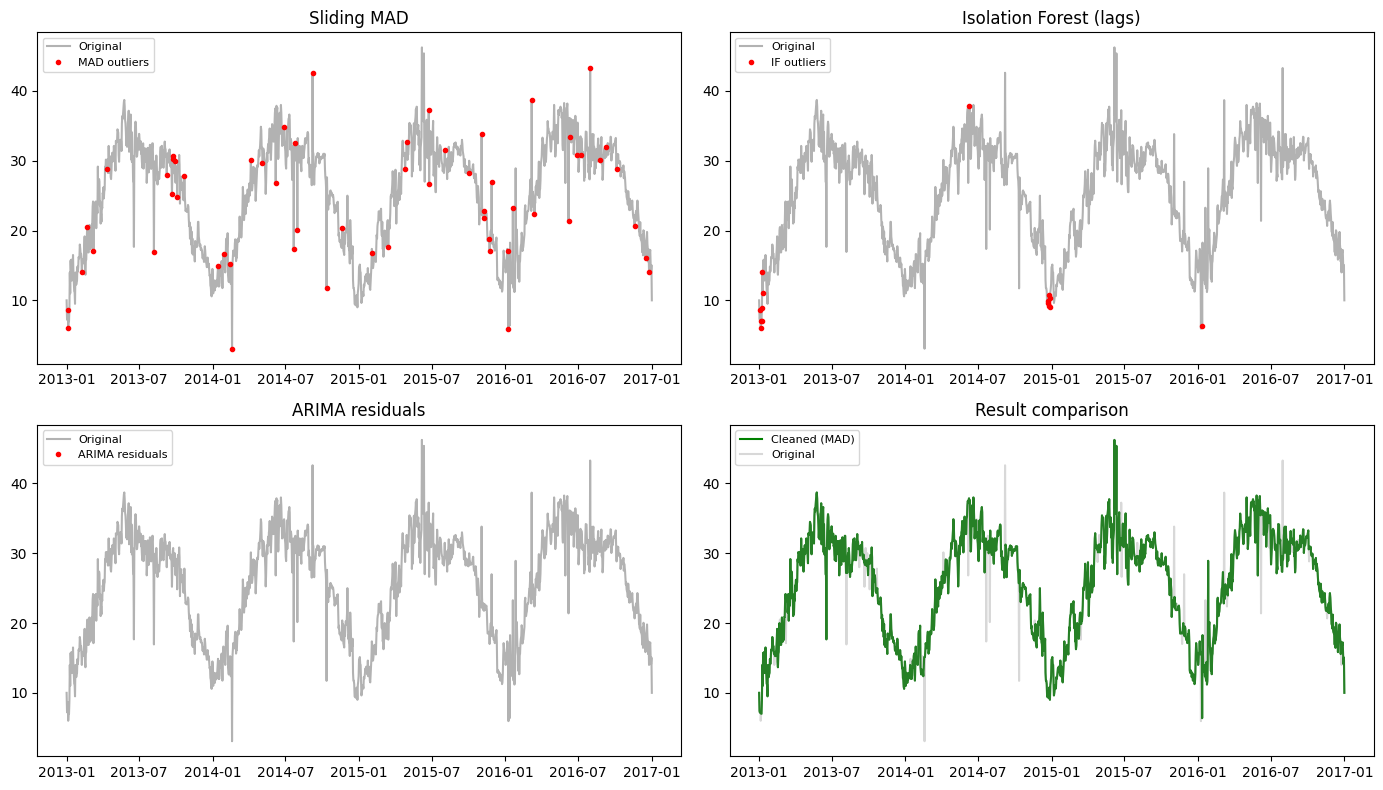

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(ts, label='Original', color='gray', alpha=0.6)
axes[0,0].plot(ts[mask_mad], 'ro', markersize=3, label='MAD outliers')
axes[0,0].set_title('Sliding MAD')
axes[0,0].legend(fontsize=8)

axes[0,1].plot(ts, label='Original', color='gray', alpha=0.6)
axes[0,1].plot(ts.iloc[len(ts)-len(outliers_iso):][outliers_iso], 'ro', markersize=3, label='IF outliers')
axes[0,1].set_title('Isolation Forest (lags)')
axes[0,1].legend(fontsize=8)

axes[1,0].plot(ts, label='Original', color='gray', alpha=0.6)
axes[1,0].plot(residuals.index[mask_arima], ts['2017-01-01':][mask_arima], 'ro', markersize=3, label='ARIMA residuals')
axes[1,0].set_title('ARIMA residuals')
axes[1,0].legend(fontsize=8)

axes[1,1].plot(ts_smooth, label='Cleaned (MAD)', color='green')
axes[1,1].plot(ts, label='Original', color='gray', alpha=0.3)
axes[1,1].set_title('Result comparison')
axes[1,1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Скользящая медиана (MAD) выявила наибольшее число аномалий, эффективно убирая резкие скачки, но может затрагивать допустимые сезонные экстремумы.
Isolation Forest оказался слишком консервативным, отметив только единичные провалы в начале ряда и несколько в середине.
Метод на основе остатков ARIMA не зафиксировал выбросов при пороге 3σ, что говорит о хорошем соответствии модели данным или необходимости снижения порога.
Для финальной обработки выбран вариант со скользящей медианой, так как он даёт наиболее стабильный ряд, сохраняя общую динамику, но убирая явные шумы.